#### This notebook asks the question "are there cases where different labels have similar vectors". For each pixel represented in the embeddings, find its k-nearest neighbors in embedding space. Then, it examines the label-agreement of those neighbors.  

### Setup

Everything this notebook writes goes to `data/knn_trajectory_2019_2024/`: the cached trajectory, neighbor arrays for both searches, the agreement tables and the figures.

In [2]:
import json
import sys
import time
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import arrays as array_io
from features import YEARS_2017_2019, emb_cols
from folds import assign_folds, log_fold_stats
from population_stats import load_population_stats

ARRAY_DIR = ROOT / "data/arrays_2019_2024"
POPULATION_STATS_PATH = ROOT / "data/population_stats_2019_2024.json"
OUT_DIR = ROOT / "data/knn_trajectory_2019_2024"
OUT_DIR.mkdir(parents=True, exist_ok=True)
TRAJ_PATH = OUT_DIR / "traj_2019_minus_2017.npy"

K = 100
N_NEG_QUERIES = 1_000_000
# Same seed and split count as train.py, so fold f here holds the same blocks
# as validation fold f in a model run on this artifact.
SEED = 0
N_SPLITS = 5

CLASS_NAMES = {0: "remained wetland", 1: "converted to developed", 2: "converted to other land cover"}

In [3]:
arrays, manifest = array_io.load_arrays(
    ARRAY_DIR, optional=("label_raw",), emb_columns=emb_cols(YEARS_2017_2019)
)
label = arrays["label"]
label_raw = np.array(arrays["label_raw"])
block_code = arrays["block_code"]
n_rows = len(label)

# label.npy is label_raw == 1 written as binary, so the two have to agree exactly.
assert np.array_equal(label == 1, label_raw == 1)

population_stats = load_population_stats(POPULATION_STATS_PATH)
assert population_stats["total_rows"] == manifest["total_rows"] == n_rows
assert population_stats["source_parquet_path"] == manifest["source_parquet_path"]

fold_assignment = assign_folds(population_stats["block_row_counts"], N_SPLITS, SEED)
fold_code = array_io.fold_of_code(manifest, fold_assignment)
row_fold = array_io.fold_of_row(arrays, fold_code)
log_fold_stats(label, row_fold, fold_assignment, N_SPLITS)

class_counts = np.bincount(label_raw, minlength=3)
class_share = class_counts / n_rows
for c, name in CLASS_NAMES.items():
    print(f"{c}  {name:<30} {class_counts[c]:>12,}  {class_share[c]:.4%}")

fold    blocks          rows   positives   pos_rate
   0       371    11,866,780      29,390    0.2477%
   1       335    11,845,125      39,123    0.3303%
   2       336    11,841,089      30,462    0.2573%
   3       344    11,854,236      30,405    0.2565%
   4       341    11,860,101      36,528    0.3080%
0  remained wetland                 58,878,170  99.3434%
1  converted to developed              165,908  0.2799%
2  converted to other land cover       223,253  0.3767%


### Embedding trajectory

`emb.npy` holds 64 AlphaEarth dims each for 2017, 2018 and 2019. The trajectory is 2019 minus 2017 per pixel. It is all before the 2019 to 2024 label window, so no label information leaks in.

The first run reads all 22.8 GB of `emb.npy` once and caches the result as a 7.6 GB float16 file. Later runs load the cache, after checking it came from the same array build.

In [4]:
cols = manifest["emb_columns"]
start_2017 = cols.index("A00_2017")
start_2019 = cols.index("A00_2019")
# The slices below assume each year's 64 dims sit together in A00 to A63 order,
# which is how emb_cols lays them out. Check rather than trust it.
assert cols[start_2017:start_2017 + 64] == [f"A{d:02d}_2017" for d in range(64)]
assert cols[start_2019:start_2019 + 64] == [f"A{d:02d}_2019" for d in range(64)]

traj_meta = {
    "definition": "A00_2019..A63_2019 minus A00_2017..A63_2017",
    "source_array_dir": str(ARRAY_DIR.relative_to(ROOT)),
    "source_built_utc": manifest["built_utc"],
    "source_git_commit": manifest["git_commit"],
}

if TRAJ_PATH.exists():
    # A trajectory left over from an older array build would still load fine
    # and give quietly wrong neighbors, so refuse it.
    with open(TRAJ_PATH.with_suffix(".json")) as fh:
        if json.load(fh) != traj_meta:
            raise ValueError(f"{TRAJ_PATH} was built from a different array artifact, delete it and rebuild")
    traj = np.load(TRAJ_PATH)
else:
    emb = arrays["emb"]
    traj = np.empty((n_rows, 64), dtype=np.float16)
    chunk = 1_000_000
    t0 = time.time()
    for s in range(0, n_rows, chunk):
        e19 = emb[s:s + chunk, start_2019:start_2019 + 64].astype(np.float32)
        e17 = emb[s:s + chunk, start_2017:start_2017 + 64].astype(np.float32)
        traj[s:s + chunk] = e19 - e17
    print(f"built trajectory in {time.time() - t0:.0f} s")
    np.save(TRAJ_PATH, traj)
    with open(TRAJ_PATH.with_suffix(".json"), "w") as fh:
        json.dump(traj_meta, fh, indent=2)

print(traj.shape, traj.dtype, f"{traj.nbytes / 1e9:.1f} GB")

(59267331, 64) float16 7.6 GB


### Query sample

Every pixel is searchable, but only a sample asks for neighbors: all converted to developed, all converted to other, and about 1M remained wetland pixels spread evenly across blocks. Keeping the search set whole matters: at a 10 percent sample, the 10th neighbor would sit about as far away as the 100th does in the full set, and the curves would no longer mean the same thing.

In [5]:
rng = np.random.default_rng(SEED)

pos_rows = np.flatnonzero(label_raw == 1)
other_rows = np.flatnonzero(label_raw == 2)

# Evenly across blocks means one cap on remained wetland pixels per block, with
# small blocks giving all they have. A plain random draw would hand most of the
# sample to the handful of huge wetland blocks.
neg_rows_all = np.flatnonzero(label_raw == 0)
neg_block = block_code[neg_rows_all].astype(np.int64)
neg_per_block = np.bincount(neg_block, minlength=manifest["n_blocks"])

lo, hi = 1, int(neg_per_block.max())
while lo < hi:
    mid = (lo + hi) // 2
    if np.minimum(neg_per_block, mid).sum() >= N_NEG_QUERIES:
        hi = mid
    else:
        lo = mid + 1
cap = lo

# Sort by block, random order inside each block, then keep the first cap rows
# of every block.
order = np.lexsort((rng.random(len(neg_rows_all)), neg_block))
sorted_block = neg_block[order]
block_start = np.concatenate([[0], np.cumsum(neg_per_block)[:-1]])
rank = np.arange(len(order)) - block_start[sorted_block]
neg_rows = neg_rows_all[order[rank < cap]]
del neg_rows_all, neg_block, order, sorted_block, rank

query_rows = np.sort(np.concatenate([pos_rows, other_rows, neg_rows]))
query_class = label_raw[query_rows]
query_fold = row_fold[query_rows]

print(f"per block cap on remained wetland queries: {cap:,}")
pd.crosstab(pd.Series(query_fold, name="fold"),
            pd.Series(query_class, name="class").map(CLASS_NAMES), margins=True)

per block cap on remained wetland queries: 594


class,converted to developed,converted to other land cover,remained wetland,All
fold,,,,
0,29390,42735,214832,286957
1,39123,41864,193632,274619
2,30462,51163,194218,275843
3,30405,40692,200463,271560
4,36528,46799,197326,280653
All,165908,223253,1000471,1389632


### Nearest neighbor search

Exact brute force L2 on the GPU. L2 rather than cosine because the size of the change is signal: a stable pixel has a tiny difference vector whose direction is mostly noise, and cosine would treat it like a big change.

Two searches, each keeping K = 100 neighbors per query:

1. Fold excluded: five passes, one per fold, each searching only the other four folds.
2. No exclusion: all 59M pixels, dropping the query itself. All 59M do not fit on the T4 as one index, so it searches one fold at a time and merges the results, which gives the same answer.

Both save their neighbors to disk, and the agreement cell reads them back from there, so after a kernel restart you can skip any search that already finished.

In [6]:
res = faiss.StandardGpuResources()


def build_index(keep=None, chunk=2_000_000):
    """Exact L2 index on the GPU over the traj rows where keep is True, or all
    rows if keep is None. faiss ids are positions in add order, so id i is the
    ith kept row, np.flatnonzero(keep)[i]."""
    cfg = faiss.GpuIndexFlatConfig()
    cfg.device = 0
    # float16 storage is what fits 59M x 64 on the T4 (7.6 GB of 15). traj is
    # float16 already, so this costs no precision we had.
    cfg.useFloat16 = True
    index = faiss.GpuIndexFlatL2(res, traj.shape[1], cfg)
    for s in range(0, n_rows, chunk):
        x = traj[s:s + chunk]
        if keep is not None:
            x = x[keep[s:s + chunk]]
        index.add(np.ascontiguousarray(x, dtype=np.float32))
    return index


def search(index, rows, k, batch=65_536):
    D = np.empty((len(rows), k), dtype=np.float32)
    I = np.empty((len(rows), k), dtype=np.int64)
    for s in range(0, len(rows), batch):
        x = np.ascontiguousarray(traj[rows[s:s + batch]], dtype=np.float32)
        D[s:s + batch], I[s:s + batch] = index.search(x, k)
    # faiss pads with -1 when it finds fewer than k, which should never happen
    # against tens of millions of rows.
    assert (I >= 0).all()
    return D, I

In [7]:
# Queries in fold f only see pixels from the other folds, so no neighbor can
# come from the query's own block. It is the same wall train.py puts between
# train and validation.
nbr_excl = np.empty((len(query_rows), K), dtype=np.int32)
dist_excl = np.empty((len(query_rows), K), dtype=np.float32)
t0 = time.time()
for f in range(N_SPLITS):
    in_db = row_fold != f
    db_rows = np.flatnonzero(in_db)
    q = np.flatnonzero(query_fold == f)
    index = build_index(in_db)
    D, I = search(index, query_rows[q], K)
    nbr_excl[q] = db_rows[I]
    dist_excl[q] = D
    del index, D, I
    print(f"fold {f}: {len(db_rows):,} searchable, {len(q):,} queries, {time.time() - t0:.0f} s so far")

np.savez(OUT_DIR / "knn_fold_excluded.npz", query_rows=query_rows, nbr_rows=nbr_excl, nbr_dist=dist_excl)

fold 0: 47,400,551 searchable, 286,957 queries, 1490 s so far
fold 1: 47,422,206 searchable, 274,619 queries, 2954 s so far
fold 2: 47,426,242 searchable, 275,843 queries, 4396 s so far
fold 3: 47,413,095 searchable, 271,560 queries, 5804 s so far
fold 4: 47,407,230 searchable, 280,653 queries, 7257 s so far


In [9]:
# One index over all 59M rows does not fit: FAISS grows its buffer by allocating
# a bigger one and copying, so near the end the old and new buffers are both on
# the T4. Search one fold at a time instead (about 1.5 GB each) and merge. Every
# shard ranks with the same exact L2, so the best K + 1 across shards is the
# best K + 1 over all pixels.
t0 = time.time()
D_parts, I_parts = [], []
for f in range(N_SPLITS):
    in_shard = row_fold == f
    shard_rows = np.flatnonzero(in_shard)
    index = build_index(in_shard)
    D, I = search(index, query_rows, K + 1)
    del index
    D_parts.append(D)
    I_parts.append(shard_rows[I].astype(np.int32))
    print(f"shard {f}: {len(shard_rows):,} rows, {time.time() - t0:.0f} s so far")

D = np.concatenate(D_parts, axis=1)
I = np.concatenate(I_parts, axis=1)
del D_parts, I_parts
order = np.argsort(D, axis=1, kind="stable")[:, :K + 1]
D = np.take_along_axis(D, order, axis=1)
I = np.take_along_axis(I, order, axis=1)
del order

# The query is in the search set too, so K + 1 came back and it gets dropped.
# It is usually the first hit, but duplicate trajectories tie it at distance
# zero, and float16 rounding can put a twin ahead of it. If more than K twins
# crowd it out entirely, drop the last hit instead so every row keeps K.
is_self = I == query_rows[:, None]
print(f"queries whose own row was not in the top {K + 1}: {int((~is_self.any(axis=1)).sum()):,}")
is_self[~is_self.any(axis=1), -1] = True
keep = ~is_self
nbr_all = I[keep].reshape(-1, K)
dist_all = D[keep].reshape(-1, K)
del D, I, is_self, keep
print(f"no exclusion: {len(query_rows):,} queries, {time.time() - t0:.0f} s")

np.savez(OUT_DIR / "knn_no_exclusion.npz", query_rows=query_rows, nbr_rows=nbr_all, nbr_dist=dist_all)

shard 0: 11,866,780 rows, 1592 s so far
shard 1: 11,845,125 rows, 3241 s so far
shard 2: 11,841,089 rows, 4894 s so far
shard 3: 11,854,236 rows, 6549 s so far
shard 4: 11,860,101 rows, 8202 s so far
queries whose own row was not in the top 101: 0
no exclusion: 1,389,632 queries, 8219 s


### Label agreement

Agreement is computed on the three class `label_raw`, so a converted to other query only counts converted to other neighbors as agreeing. For converted to developed queries this is the same as the share of neighbors that are positive.

Raw agreement means little next to a class that is 99 percent of the data, so the table also gives chance and the lift over chance.

In [10]:
def agreement_by_k(nbr_rows):
    """For k = 1 to K and each query class: mean share of the first k neighbors
    whose label_raw matches the query's, and the share of queries with no
    matching neighbor at all in the first k."""
    match = label_raw[nbr_rows] == query_class[:, None]
    n_agree = np.cumsum(match, axis=1, dtype=np.int16)
    ks = np.arange(1, K + 1)
    out = {}
    for c in CLASS_NAMES:
        m = n_agree[query_class == c]
        out[c] = {"mean": m.mean(axis=0) / ks, "none": (m == 0).mean(axis=0)}
    return out


def load_neighbors(name):
    """Neighbor rows from a saved search, so a kernel restart does not mean
    redoing hours of GPU work. The query sample is seeded, so a fresh run of the
    sampling cell has to reproduce the saved query rows exactly."""
    saved = np.load(OUT_DIR / f"knn_{name}.npz")
    if not np.array_equal(saved["query_rows"], query_rows):
        raise ValueError(f"knn_{name}.npz was built from a different query sample, rerun its search cell")
    return saved["nbr_rows"]


curves = {name: agreement_by_k(load_neighbors(name)) for name in ("fold_excluded", "no_exclusion")}

# Chance is the class's share of all pixels, what a query would score if its
# neighbors were drawn at random. The fold excluded search set is about 80
# percent of the pixels, so its real chance level moves a little from fold to fold.
REPORT_K = (1, 5, 10, 25, 50, 100)
rows = []
for mode, by_class in curves.items():
    for c, name in CLASS_NAMES.items():
        for k in REPORT_K:
            agreement = by_class[c]["mean"][k - 1]
            rows.append({
                "search": mode,
                "query class": name,
                "n queries": int((query_class == c).sum()),
                "k": k,
                "agreement": agreement,
                "chance": class_share[c],
                "lift over chance": agreement / class_share[c],
                "share with no agreeing neighbor": by_class[c]["none"][k - 1],
            })
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "agreement_by_k.csv", index=False)
summary.round(4)

,search,query class,n queries,k,agreement,chance,lift over chance,share with no agreeing neighbor
0,fold_excluded,remained wetland,1000471,1,0.9913,0.9934,0.9979,0.0087
1,fold_excluded,remained wetland,1000471,5,0.9916,0.9934,0.9982,0.0002
2,fold_excluded,remained wetland,1000471,10,0.9918,0.9934,0.9984,0.0001
3,fold_excluded,remained wetland,1000471,25,0.9920,0.9934,0.9986,0.0000
4,fold_excluded,remained wetland,1000471,50,0.9922,0.9934,0.9987,0.0000
5,fold_excluded,remained wetland,1000471,100,0.9923,0.9934,0.9989,0.0000
6,fold_excluded,converted to developed,165908,1,0.0767,0.0028,27.4122,0.9233
7,fold_excluded,converted to developed,165908,5,0.0698,0.0028,24.9519,0.8142
8,fold_excluded,converted to developed,165908,10,0.0658,0.0028,23.5000,0.7316
9,fold_excluded,converted to developed,165908,25,0.0594,0.0028,21.2024,0.5839


### Agreement against k

One panel per query class, each with its own y axis because the classes live at very different agreement levels (remained wetland is near 99 percent just by being the majority). The dotted line is chance, the class's share of all 59,267,331 pixels. Blue is the fold excluded search, orange is no exclusion. The gap between them is how much of the agreement comes from pixels in the same block, which is spatial autocorrelation rather than the embedding separating the classes.

Queries: all 165,908 converted to developed pixels (0.28 percent of all pixels), all 223,253 converted to other, and about 1M remained wetland pixels capped per block. Exact counts and the cap are printed in the sampling cell.

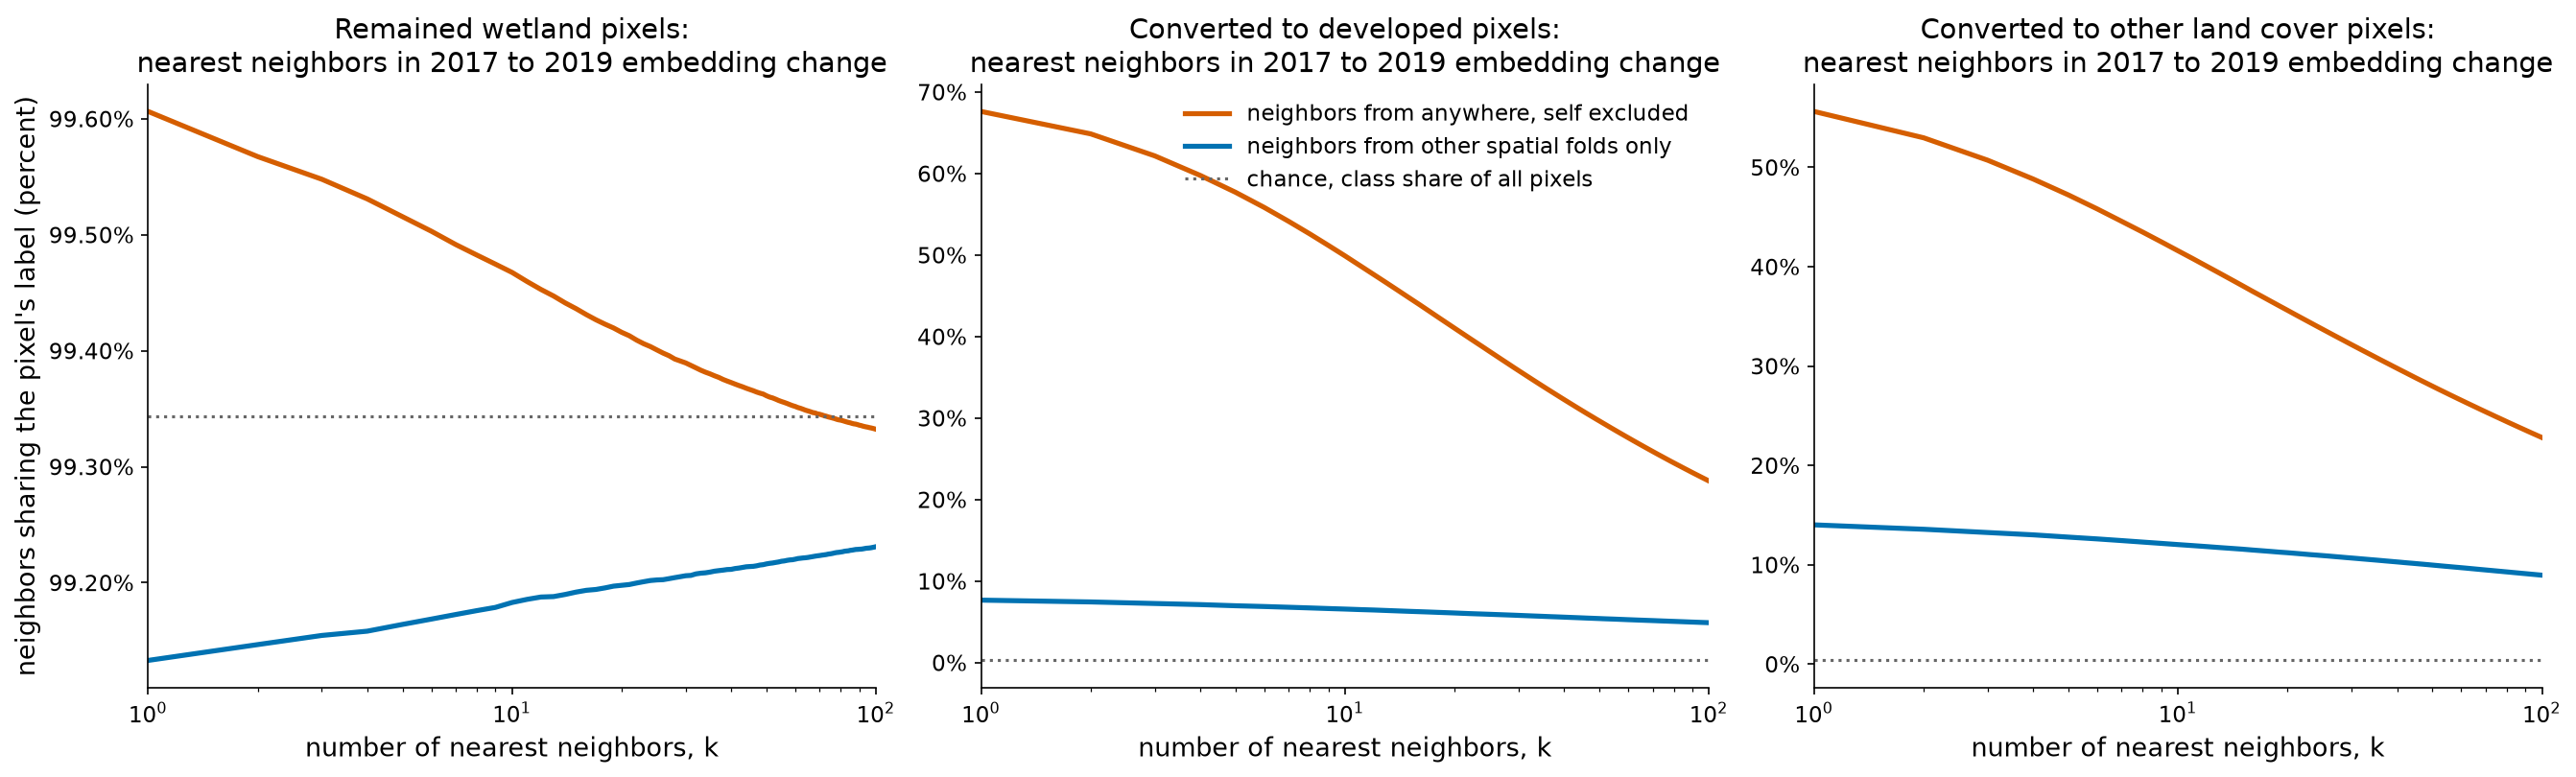

In [11]:
COLORS = {"fold_excluded": "#0072B2", "no_exclusion": "#D55E00"}
LEGEND = {
    "fold_excluded": "neighbors from other spatial folds only",
    "no_exclusion": "neighbors from anywhere, self excluded",
}
ks = np.arange(1, K + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=150)
for ax, (c, name) in zip(axes, CLASS_NAMES.items()):
    for mode in ("no_exclusion", "fold_excluded"):
        ax.plot(ks, curves[mode][c]["mean"], color=COLORS[mode], linewidth=2.5, label=LEGEND[mode])
    ax.axhline(class_share[c], color="#666666", linestyle=":", linewidth=1.5,
               label="chance, class share of all pixels")
    ax.set_xscale("log")
    ax.set_xlim(1, K)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(f"{name.capitalize()} pixels:\nnearest neighbors in 2017 to 2019 embedding change", fontsize=14)
    ax.set_xlabel("number of nearest neighbors, k", fontsize=13)
    ax.tick_params(labelsize=11)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("neighbors sharing the pixel's label (percent)", fontsize=13)
# Converted to developed sits far below the other panels' ranges, so its panel
# has the most empty space for the legend.
axes[1].legend(fontsize=11, frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "agreement_vs_k.png", bbox_inches="tight")
plt.show()

### Near and far neighbors

The gap between the two searches mixes a few things together, so this looks at spatial autocorrelation directly. For every query and neighbor pair from both saved searches, it takes the distance between the two pixels on the ground from `xy.npy` and groups the pairs into distance bands. Agreement in each band is agreeing pairs over pairs, pooled over all queries of a class. It is pooled rather than averaged per query because most queries have no neighbors at all in some bands.

The table gives agreement per band three ways: all 100 ranks, ranks 1 to 10 only, and ranks 51 to 100 only. If agreement still falls with distance inside each rank group, the drop is geographic and not just the closest vectors agreeing more. Pair counts, share of pairs, and lift are in `agreement_by_ground_distance.csv`. No GPU needed, this runs off the saved neighbor files.

In [12]:
# Projected meters on the 30 m NLCD grid: rows next to each other in a scan
# line sit exactly 30 m apart in x.
xy = np.load(ARRAY_DIR / "xy.npy")
query_xy = xy[query_rows]

# Roughly 3x steps. The first band is the pixel's own surroundings (the next
# pixel over is 30 to 42 m away), the last is another part of the state.
# Moran's I on the label fades slowly with no clean cutoff (0.57 at 30 m, still
# 0.12 at 3.8 km), which is why this uses bands instead of one near/far split.
BAND_EDGES_M = np.array([100, 300, 1_000, 3_000, 10_000, 30_000, 100_000])
BAND_LABELS = ["under 100 m", "100 to 300 m", "300 m to 1 km", "1 to 3 km",
               "3 to 10 km", "10 to 30 km", "30 to 100 km", "over 100 km"]
N_BANDS = len(BAND_LABELS)
MIN_PAIRS = 1_000

# Close on the ground usually also means close in embedding space, rank 1 to 5,
# and close ranks agree more wherever they are. Splitting by rank checks whether
# the drop with distance survives at a fixed rank.
RANK_GROUPS = {"all ranks": (1, K), "ranks 1 to 10": (1, 10), "ranks 51 to 100": (51, 100)}


def ground_distance_band(nbr_rows, chunk=200_000):
    """Band index (0 to N_BANDS minus 1) for every query and neighbor pair."""
    band = np.empty(nbr_rows.shape, dtype=np.int8)
    for s in range(0, len(nbr_rows), chunk):
        d = xy[nbr_rows[s:s + chunk]] - query_xy[s:s + chunk, None, :]
        band[s:s + chunk] = np.digitize(np.hypot(d[..., 0], d[..., 1]), BAND_EDGES_M)
    return band


def pairs_by_band(nbr_rows, band, first_rank, last_rank):
    """Pair counts and agreeing pair counts, shape (3 classes, N_BANDS), pooled
    over every query and neighbor pair in the rank range."""
    ranks = slice(first_rank - 1, last_rank)
    match = label_raw[nbr_rows[:, ranks]] == query_class[:, None]
    key = query_class[:, None].astype(np.int64) * N_BANDS + band[:, ranks]
    n_pairs = np.bincount(key.ravel(), minlength=3 * N_BANDS).reshape(3, N_BANDS)
    n_agree = np.bincount(key[match], minlength=3 * N_BANDS).reshape(3, N_BANDS)
    return n_pairs, n_agree


rows = []
for mode in ("no_exclusion", "fold_excluded"):
    nbr_rows = load_neighbors(mode)
    band = ground_distance_band(nbr_rows)
    for group, (first_rank, last_rank) in RANK_GROUPS.items():
        n_pairs, n_agree = pairs_by_band(nbr_rows, band, first_rank, last_rank)
        for c, name in CLASS_NAMES.items():
            for b, band_label in enumerate(BAND_LABELS):
                n = int(n_pairs[c, b])
                agreement = n_agree[c, b] / n if n >= MIN_PAIRS else np.nan
                rows.append({
                    "search": mode,
                    "ranks": group,
                    "query class": name,
                    "band": band_label,
                    "n pairs": n,
                    "share of pairs": n / n_pairs[c].sum(),
                    "agreement": agreement,
                    "chance": class_share[c],
                    "lift over chance": agreement / class_share[c],
                })
    del nbr_rows, band

by_distance = pd.DataFrame(rows)
by_distance.to_csv(OUT_DIR / "agreement_by_ground_distance.csv", index=False)

# Agreement per band, one row per search, rank group and class. Blank cells
# had fewer than MIN_PAIRS pairs.
(by_distance
 .pivot_table(index=["search", "query class", "ranks"], columns="band", values="agreement", sort=False)
 .reindex(columns=BAND_LABELS)
 .round(4))

band                                                         under 100 m  \
search        query class                   ranks                          
no_exclusion  remained wetland              all ranks             0.9967   
                                            ranks 1 to 10         0.9964   
                                            ranks 51 to 100       0.9970   
              converted to developed        all ranks             0.6439   
                                            ranks 1 to 10         0.6671   
                                            ranks 51 to 100       0.5702   
              converted to other land cover all ranks             0.4980   
                                            ranks 1 to 10         0.5243   
                                            ranks 51 to 100       0.4480   
fold_excluded remained wetland              all ranks             0.9971   
                                            ranks 1 to 10         0.9970   
                                            ranks 51 to 100       0.9972   
              converted to developed        all ranks             0.6260   
                                            ranks 1 to 10         0.6541   
                                            ranks 51 to 100          NaN   
              converted to other land cover all ranks             0.5207   
                                            ranks 1 to 10         0.5345   
                                            ranks 51 to 100       0.4575   

band                                                         100 to 300 m  \
search        query class                   ranks                           
no_exclusion  remained wetland              all ranks              0.9959   
                                            ranks 1 to 10          0.9934   
                                            ranks 51 to 100        0.9965   
              converted to developed        all ranks              0.5167   
                                            ranks 1 to 10          0.4738   
                                            ranks 51 to 100        0.5142   
              converted to other land cover all ranks              0.4034   
                                            ranks 1 to 10          0.4112   
                                            ranks 51 to 100        0.3980   
fold_excluded remained wetland              all ranks              0.9968   
                                            ranks 1 to 10          0.9963   
                                            ranks 51 to 100        0.9968   
              converted to developed        all ranks              0.5206   
                                            ranks 1 to 10          0.5156   
                                            ranks 51 to 100        0.5118   
              converted to other land cover all ranks              0.4018   
                                            ranks 1 to 10          0.4163   
                                            ranks 51 to 100        0.3749   

band                                                         300 m to 1 km  \
search        query class                   ranks                            
no_exclusion  remained wetland              all ranks               0.9951   
                                            ranks 1 to 10           0.9919   
                                            ranks 51 to 100         0.9956   
              converted to developed        all ranks               0.2742   
                                            ranks 1 to 10           0.2310   
                                            ranks 51 to 100         0.2851   
              converted to other land cover all ranks               0.2831   
                                            ranks 1 to 10           0.2897   
                                            ranks 51 to 100         0.2820   
fold_excluded remained wetland              all ranks               0.9964   
  

### Agreement by ground distance

Columns are the three query classes. The top row is where each class's 100 nearest neighbors in trajectory space fall on the ground, as a share of all its query and neighbor pairs, so each line sums to 100 percent. The bottom row is agreement within each distance band, pooled over pairs. Orange is no exclusion, blue is fold excluded, and the dotted line is chance, the class's share of all 59,267,331 pixels. Bands with fewer than 1,000 pairs are left off.

The bottom panels for converted to developed and converted to other are on a log scale, so the distance from the chance line reads as lift. If converted to developed agreement is high in the first bands and drops to near chance past 10 km, the high agreement at small k in the previous figure is pixels matching their own parcel. If it stays well above chance far out, the trajectory carries a signal that moves between regions. Any blue share in the under 1 km bands is spatial leakage across block edges that fold exclusion does not stop.

All ranks 1 to 100 are pooled here. The rank split in the table above is the check on whether the drop with distance is geographic or just close ranks agreeing more.

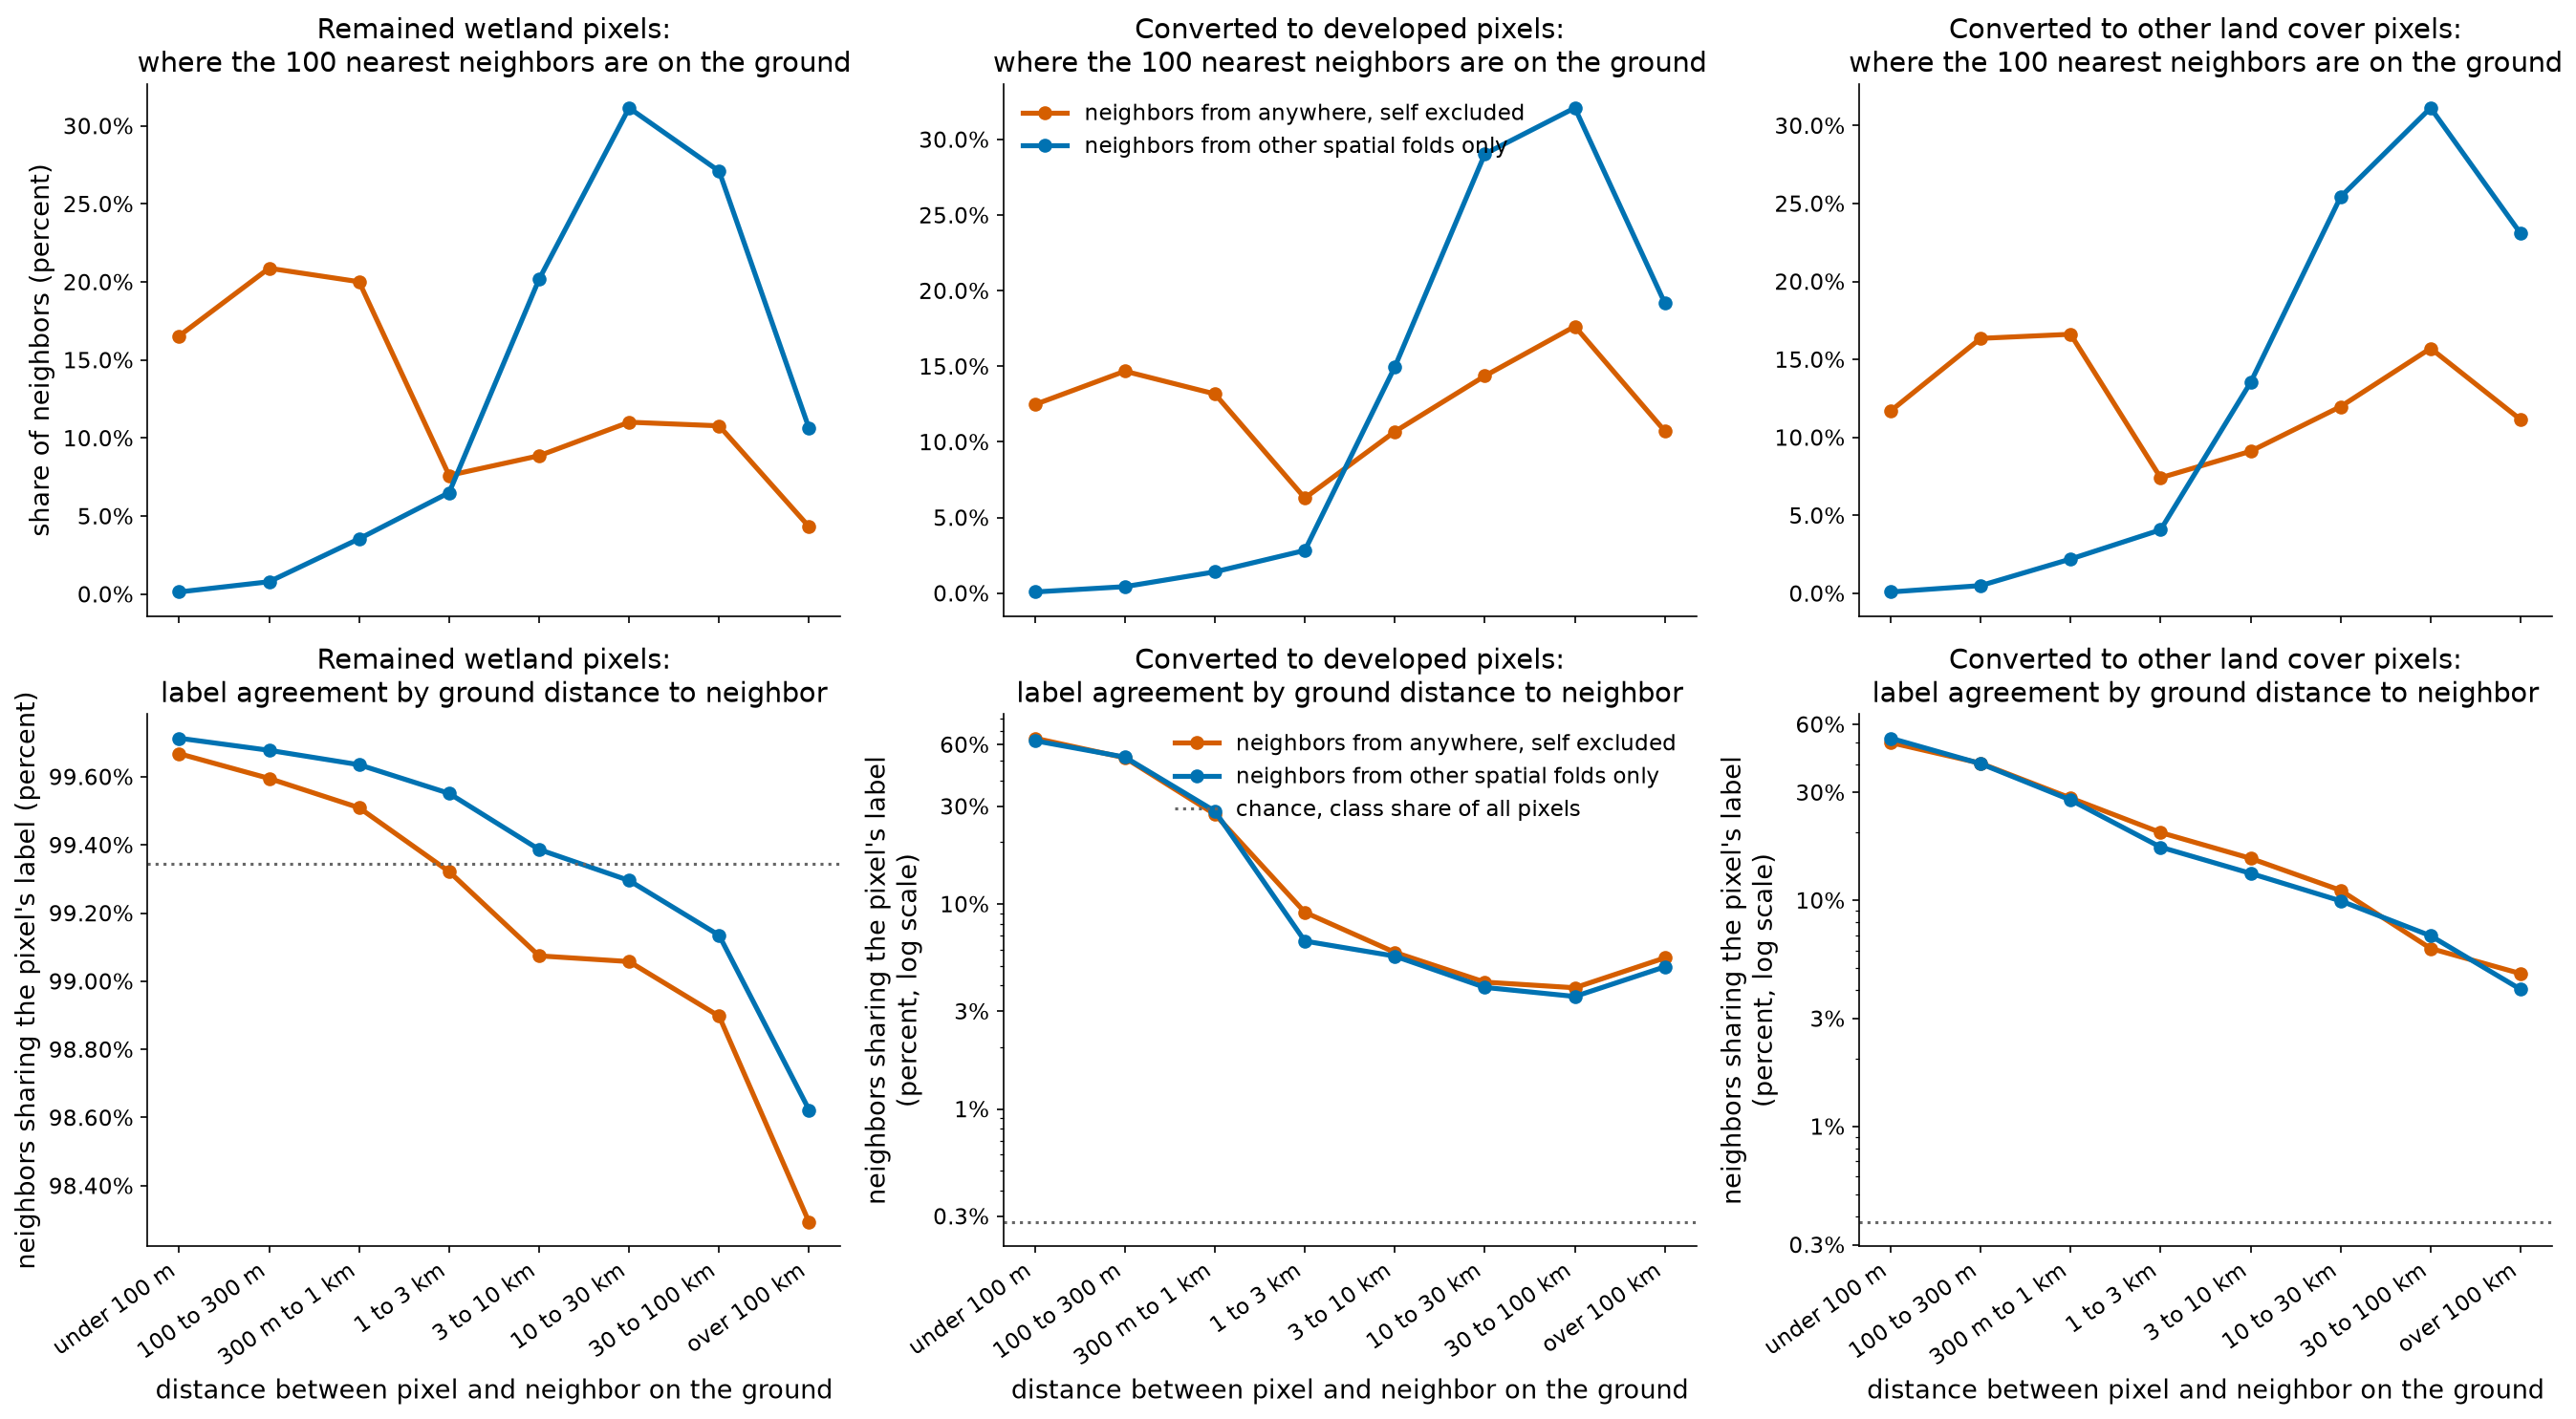

In [14]:
all_ranks = by_distance[by_distance["ranks"] == "all ranks"]
x = np.arange(N_BANDS)

# A log axis with only the 1% and 10% ticks labeled reads as if the top of the
# panel were about 20%, when the first points are at 50 to 65%.
LOG_TICKS = [0.003, 0.01, 0.03, 0.1, 0.3, 0.6]
# PercentFormatter picks its decimals from the whole axis range, which rounds
# 0.3% to "0%" on this span, so format each tick on its own.
log_percent = plt.FuncFormatter(lambda v, _: f"{v * 100:g}%")

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150, sharex=True)
for col, (c, name) in enumerate(CLASS_NAMES.items()):
    ax_share, ax_agree = axes[0, col], axes[1, col]
    for mode in ("no_exclusion", "fold_excluded"):
        d = all_ranks[(all_ranks["search"] == mode) & (all_ranks["query class"] == name)]
        d = d.set_index("band").reindex(BAND_LABELS)
        ax_share.plot(x, d["share of pairs"], color=COLORS[mode], linewidth=2.5, marker="o", label=LEGEND[mode])
        ax_agree.plot(x, d["agreement"], color=COLORS[mode], linewidth=2.5, marker="o", label=LEGEND[mode])
    ax_agree.axhline(class_share[c], color="#666666", linestyle=":", linewidth=1.5,
                     label="chance, class share of all pixels")

    ax_share.set_title(f"{name.capitalize()} pixels:\nwhere the 100 nearest neighbors are on the ground", fontsize=14)
    ax_agree.set_title(f"{name.capitalize()} pixels:\nlabel agreement by ground distance to neighbor", fontsize=14)
    for ax in (ax_share, ax_agree):
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.tick_params(labelsize=11)
        ax.spines[["top", "right"]].set_visible(False)

    # The two rare classes run from well under 1 percent to well over 50, so a
    # linear axis flattens everything past a few km onto the chance line.
    # Remained wetland sits near 99 percent throughout and stays linear.
    if c != 0:
        ax_agree.set_yscale("log")
        ax_agree.set_yticks(LOG_TICKS)
        ax_agree.yaxis.set_major_formatter(log_percent)
        ax_agree.yaxis.set_minor_formatter(plt.NullFormatter())
        ax_agree.set_ylabel("neighbors sharing the pixel's label\n(percent, log scale)", fontsize=13)

    ax_agree.set_xticks(x)
    ax_agree.set_xticklabels(BAND_LABELS, rotation=35, ha="right")
    ax_agree.set_xlabel("distance between pixel and neighbor on the ground", fontsize=13)

axes[0, 0].set_ylabel("share of neighbors (percent)", fontsize=13)
axes[1, 0].set_ylabel("neighbors sharing the pixel's label (percent)", fontsize=13)
axes[0, 1].legend(fontsize=11, frameon=False)
# Lower left sits on the chance line; the far bands leave the upper right empty.
axes[1, 1].legend(fontsize=11, frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(OUT_DIR / "agreement_by_ground_distance.png", bbox_inches="tight")
plt.show()

### Which labels the neighbors that don't match carry

Agreement only says how many neighbors share the pixel's label. This splits the 10 nearest neighbors into all three labels. It is laid out like a confusion matrix: the pixel's own label down the side, the neighbor's label across the top, and each row sums to 100 percent. Each cell shows the share of neighbors with that label and the lift over chance, which is that share divided by the label's share of all 59,267,331 pixels (99.34 percent remained wetland, 0.28 percent converted to developed, 0.38 percent converted to other). Color is lift on a log scale: purple is above chance, orange is below, white is about chance.

The diagonal is the agreement from the earlier figures. The off diagonal cells answer what the mismatches are. The two to watch are converted to developed and converted to other against each other: if those sit above 1x, the two kinds of conversion look alike before 2019, even though the binary label counts converted to other as a negative. Queries are the same 1,389,632 pixels as above. The numbers behind the figure are in `neighbor_composition_k10.csv`.

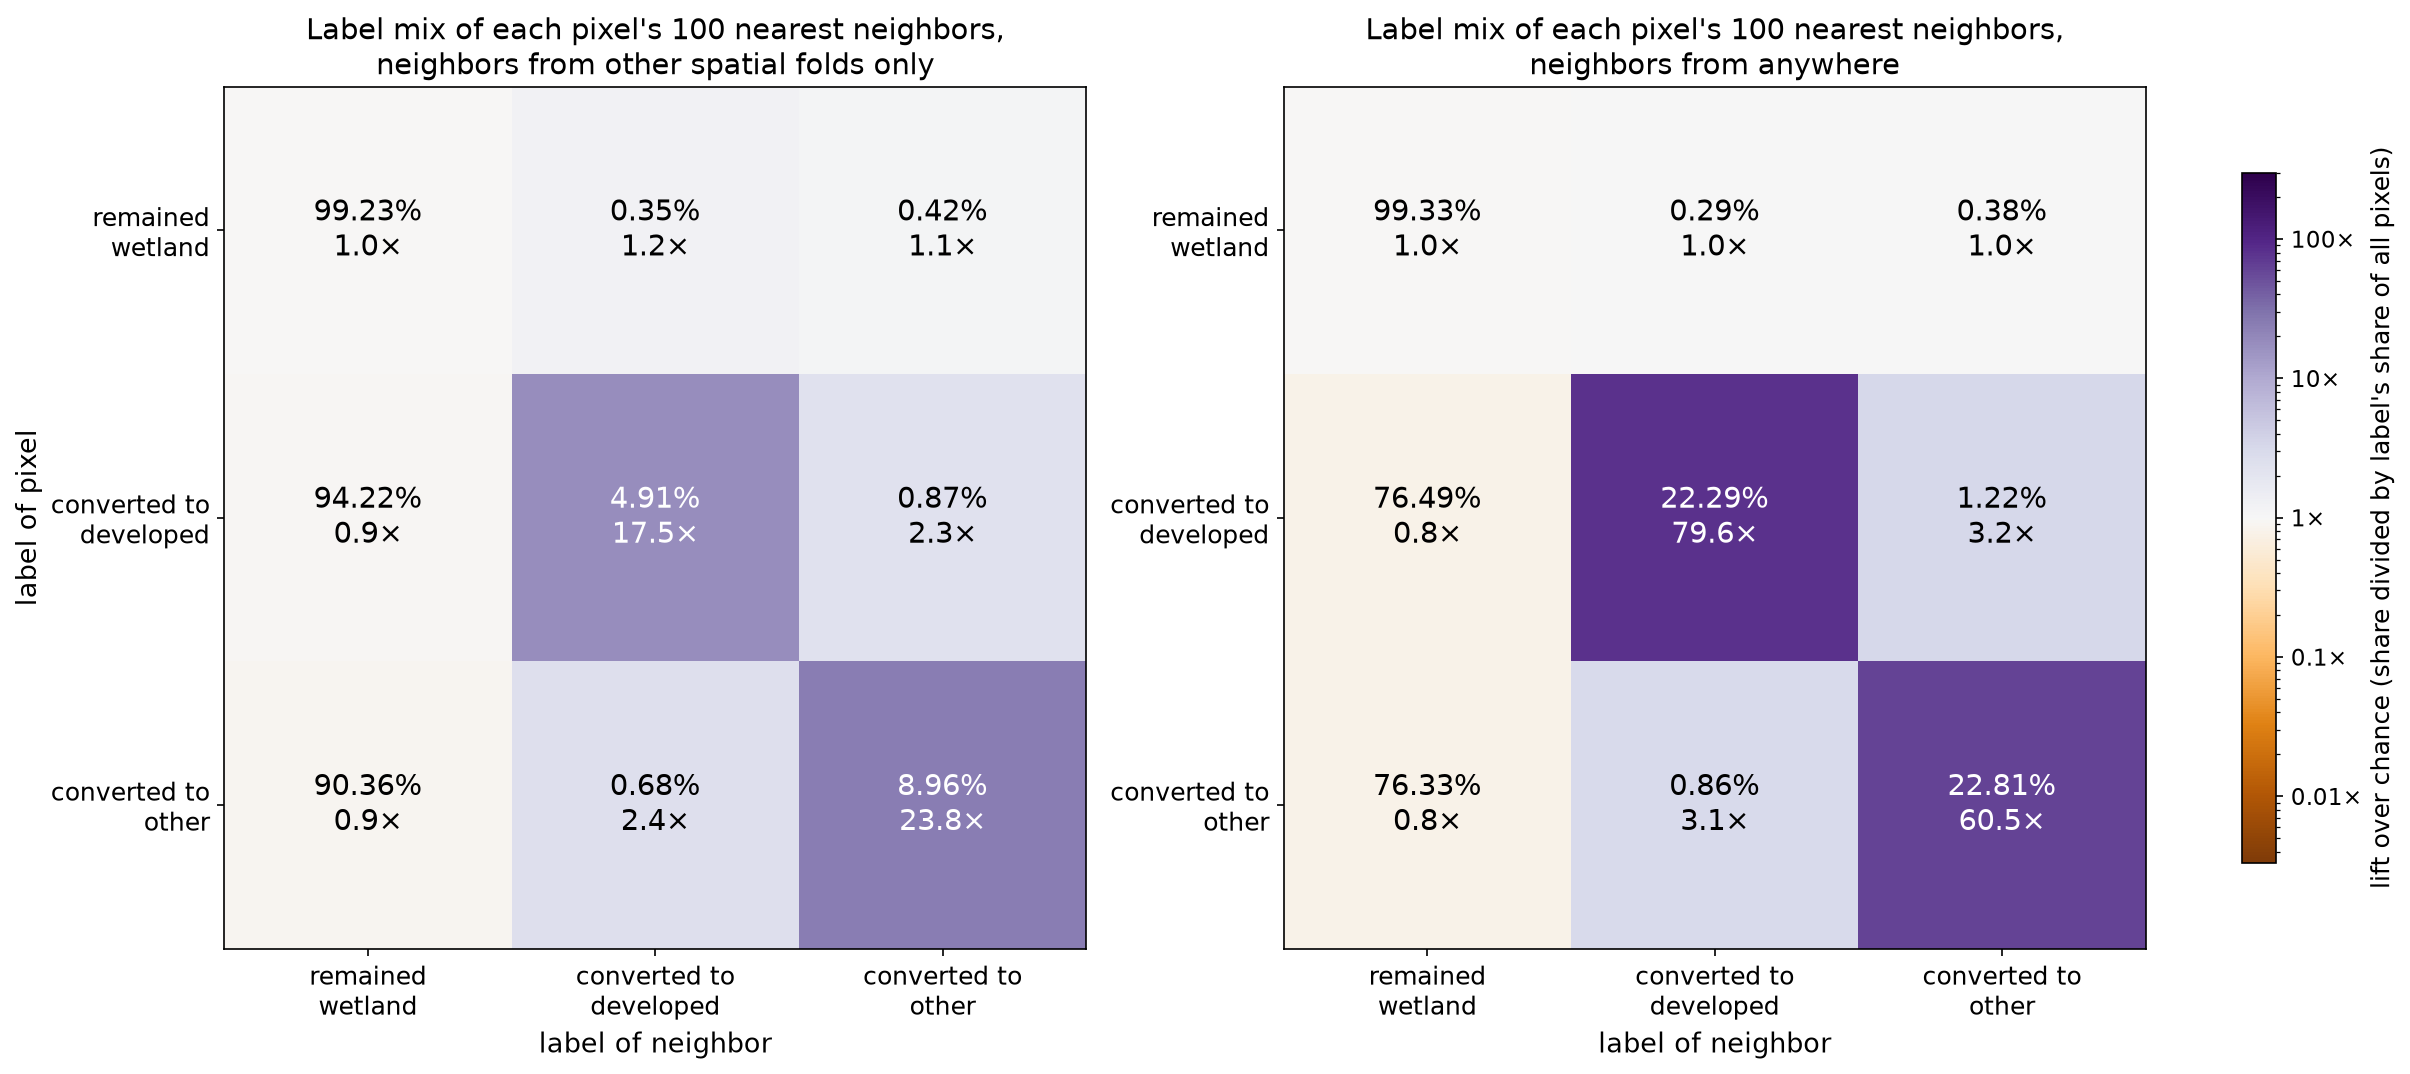

In [16]:
from matplotlib.colors import LogNorm

COMPOSITION_K = 100
SEARCHES = ("fold_excluded", "no_exclusion")


def neighbor_composition(nbr_rows, k):
    """Share of the first k neighbors carrying each label_raw class, shape
    (query class, neighbor label). Each row sums to 1."""
    nbr_label = label_raw[nbr_rows[:, :k]]
    comp = np.zeros((3, 3))
    for c in CLASS_NAMES:
        counts = np.bincount(nbr_label[query_class == c].ravel(), minlength=3)
        comp[c] = counts / counts.sum()
    return comp


composition = {mode: neighbor_composition(load_neighbors(mode), COMPOSITION_K) for mode in SEARCHES}

rows = []
for mode, comp in composition.items():
    for c, name in CLASS_NAMES.items():
        for j, nbr_name in CLASS_NAMES.items():
            rows.append({
                "search": mode,
                "query class": name,
                "neighbor label": nbr_name,
                "share of neighbors": comp[c, j],
                "chance": class_share[j],
                "lift over chance": comp[c, j] / class_share[j],
            })
composition_table = pd.DataFrame(rows)
composition_table.to_csv(OUT_DIR / f"neighbor_composition_k{COMPOSITION_K}.csv", index=False)

# Raw share is about 90 percent remained wetland in every row, which would make
# the whole grid one color. Lift on a log scale centered on 1 puts above chance
# and below chance on opposite sides of the palette.
LIFT_LIMIT = 300
norm = LogNorm(vmin=1 / LIFT_LIMIT, vmax=LIFT_LIMIT)
tick_names = ["remained\nwetland", "converted to\ndeveloped", "converted to\nother"]
panel_titles = {
    "fold_excluded": f"Label mix of each pixel's {COMPOSITION_K} nearest neighbors,\nneighbors from other spatial folds only",
    "no_exclusion": f"Label mix of each pixel's {COMPOSITION_K} nearest neighbors,\nneighbors from anywhere",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150, layout="constrained")
for ax, mode in zip(axes, SEARCHES):
    comp = composition[mode]
    lift = comp / class_share[None, :]
    im = ax.imshow(lift, cmap="PuOr", norm=norm)
    for i in range(3):
        for j in range(3):
            # White text once the cell is past the middle of the color ramp in
            # either direction, black on the pale cells near 1x.
            dark = abs(np.log(lift[i, j])) > 0.5 * np.log(LIFT_LIMIT)
            ax.text(j, i, f"{comp[i, j]:.2%}\n{lift[i, j]:.1f}×", ha="center", va="center",
                    fontsize=14, color="white" if dark else "black")
    ax.set_xticks(range(3))
    ax.set_xticklabels(tick_names, fontsize=12)
    ax.set_yticks(range(3))
    ax.set_yticklabels(tick_names, fontsize=12)
    ax.set_xlabel("label of neighbor", fontsize=13)
    ax.set_title(panel_titles[mode], fontsize=14)
axes[0].set_ylabel("label of pixel", fontsize=13)

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.8)
cbar.set_ticks([0.01, 0.1, 1, 10, 100])
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}×"))
cbar.ax.yaxis.set_minor_formatter(plt.NullFormatter())
cbar.ax.tick_params(labelsize=11)
cbar.set_label("lift over chance (share divided by label's share of all pixels)", fontsize=12)

fig.savefig(OUT_DIR / f"neighbor_composition_k{COMPOSITION_K}.png", bbox_inches="tight")
plt.show()